# Etapa 5 — Análisis de sensibilidad: 5 técnicas de clustering

**Prerrequisito**: Ejecutar `03_clustering.ipynb` primero (genera `hospital_matrix.parquet`).

## Motivación

El clustering K-means++ del notebook 03 dio K=2 con Silhouette 0.48, pero la división resultante (4 vs 61) es muy desbalanceada. Este notebook explora **5 técnicas alternativas** para responder a la observación del profesor guía:

> *"Con K=2 me entrega muy poca información. Algunas técnicas no requieren especificar K. Querría explorar un rango mayor."*

## Técnicas comparadas

| # | Método | ¿Especifica K? | Hiperparámetros |
|---|---|---|---|
| 1 | **K-means++** (referencia) | Sí | K ∈ {2..8} forzados |
| 2 | **Aglomerativo (Ward)** | Sí (corte del árbol) | K ∈ {2..8} + dendrograma |
| 3 | **HDBSCAN** | **No** | min_cluster_size ∈ {3, 4, 5, 6, 8} |
| 4 | **KNN-graph + Leiden** | **No** | k_nn ∈ {10, 15, 20}, res ∈ {0.5, 1.0, 1.5, 2.0} |
| 5 | **Gaussian Mixture (BIC)** | Sí (con criterio bayesiano) | K ∈ {2..8} |

## Outputs

- `reports/tables/clustering_alternativos_comparacion.csv`: tabla unificada con métricas
- `reports/tables/clustering_alternativos_ari_cruzado.csv`: ARI entre todos los pares
- `reports/figures/dendrograma_ward.png`: dendrograma con cortes a K=2..6
- `reports/figures/clustering_alternativos_pca2d.png`: visualización 2D de cada método

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

assert np.__version__.startswith('1.'), 'NumPy debe ser 1.x'

from src.modeling.cluster import Preprocesador
from src.modeling.cluster_alternativos import (
    aglomerativo_rango, comparar_etiquetas, gmm_rango,
    hdbscan_rango, kmeans_rango, knn_leiden_rango,
    HDBSCAN_DISPONIBLE, LEIDEN_DISPONIBLE,
)
from src.utils.io import FIGURES_DIR, TABLES_DIR, read_parquet

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid', font_scale=1.05)
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

print(f'HDBSCAN disponible:  {HDBSCAN_DISPONIBLE}')
print(f'Leiden disponible:   {LEIDEN_DISPONIBLE}')

HDBSCAN disponible:  True
Leiden disponible:   True


## 5.1 Carga + preprocesamiento

In [2]:
matriz = read_parquet('hospital_matrix')
prep = Preprocesador()
X_scaled = prep.transform(matriz)
print(f'Hospital_Matrix_Integrada: {matriz.shape}')
print(f'X_scaled (post log1p + RobustScaler): {X_scaled.shape}')

X = X_scaled.values
ids_hospitales = X_scaled.index.values
n = len(X)
print(f'\nHospitales: {n}')

Hospital_Matrix_Integrada: (65, 20)
X_scaled (post log1p + RobustScaler): (65, 18)

Hospitales: 65


## 5.2 Método 1 — K-means++ con K ∈ {2..8}

In [3]:
df_kmeans, labels_kmeans = kmeans_rango(X, k_grid=tuple(range(2, 9)))
print('K-means++ — métricas por K:')
print(df_kmeans.to_string(index=False))

# Distribución de hospitales por cluster para cada K
print('\nDistribución por cluster:')
for k, labs in labels_kmeans.items():
    dist = pd.Series(labs).value_counts().sort_index().tolist()
    print(f'  K={k}: {dist}')

K-means++ — métricas por K:
   metodo config  n_clusters_efectivos  silhouette  calinski_harabasz  davies_bouldin
K-means++    K=2                     2      0.4845            10.8606          1.5133
K-means++    K=3                     3      0.2521             9.6682          1.7273
K-means++    K=4                     4      0.2441            10.1843          1.3051
K-means++    K=5                     5      0.1550            10.6064          1.1416
K-means++    K=6                     6      0.1245            11.2223          1.2765
K-means++    K=7                     7      0.1466            11.1916          1.2241
K-means++    K=8                     8      0.1425            11.6595          1.1920

Distribución por cluster:
  K=2: [4, 61]
  K=3: [17, 45, 3]
  K=4: [3, 16, 45, 1]
  K=5: [1, 24, 36, 3, 1]
  K=6: [26, 26, 3, 8, 1, 1]
  K=7: [29, 14, 1, 1, 13, 4, 3]
  K=8: [21, 19, 4, 14, 3, 1, 1, 2]


## 5.3 Método 2 — Aglomerativo (Ward) + dendrograma

In [4]:
df_agg, labels_agg = aglomerativo_rango(X, k_grid=tuple(range(2, 9)))
print('Aglomerativo Ward — métricas por K:')
print(df_agg.to_string(index=False))

print('\nDistribución por cluster:')
for k, labs in labels_agg.items():
    dist = pd.Series(labs).value_counts().sort_index().tolist()
    print(f'  K={k}: {dist}')

Aglomerativo Ward — métricas por K:


             metodo config  n_clusters_efectivos  silhouette  calinski_harabasz  davies_bouldin
Aglomerativo (Ward)    K=2                     2      0.4845            10.8606          1.5133
Aglomerativo (Ward)    K=3                     3      0.3784            10.2876          1.3270
Aglomerativo (Ward)    K=4                     4      0.2991            10.5209          1.2978
Aglomerativo (Ward)    K=5                     5      0.3032            10.6956          1.0318
Aglomerativo (Ward)    K=6                     6      0.1157            10.7359          1.4362
Aglomerativo (Ward)    K=7                     7      0.1187            11.0717          1.2325
Aglomerativo (Ward)    K=8                     8      0.1309            11.3213          1.2133



Distribución por cluster:
  K=2: [61, 4]
  K=3: [58, 4, 3]
  K=4: [4, 53, 3, 5]
  K=5: [53, 3, 3, 5, 1]
  K=6: [3, 30, 23, 5, 1, 3]
  K=7: [30, 2, 23, 5, 1, 3, 1]
  K=8: [2, 19, 23, 11, 1, 3, 1, 5]


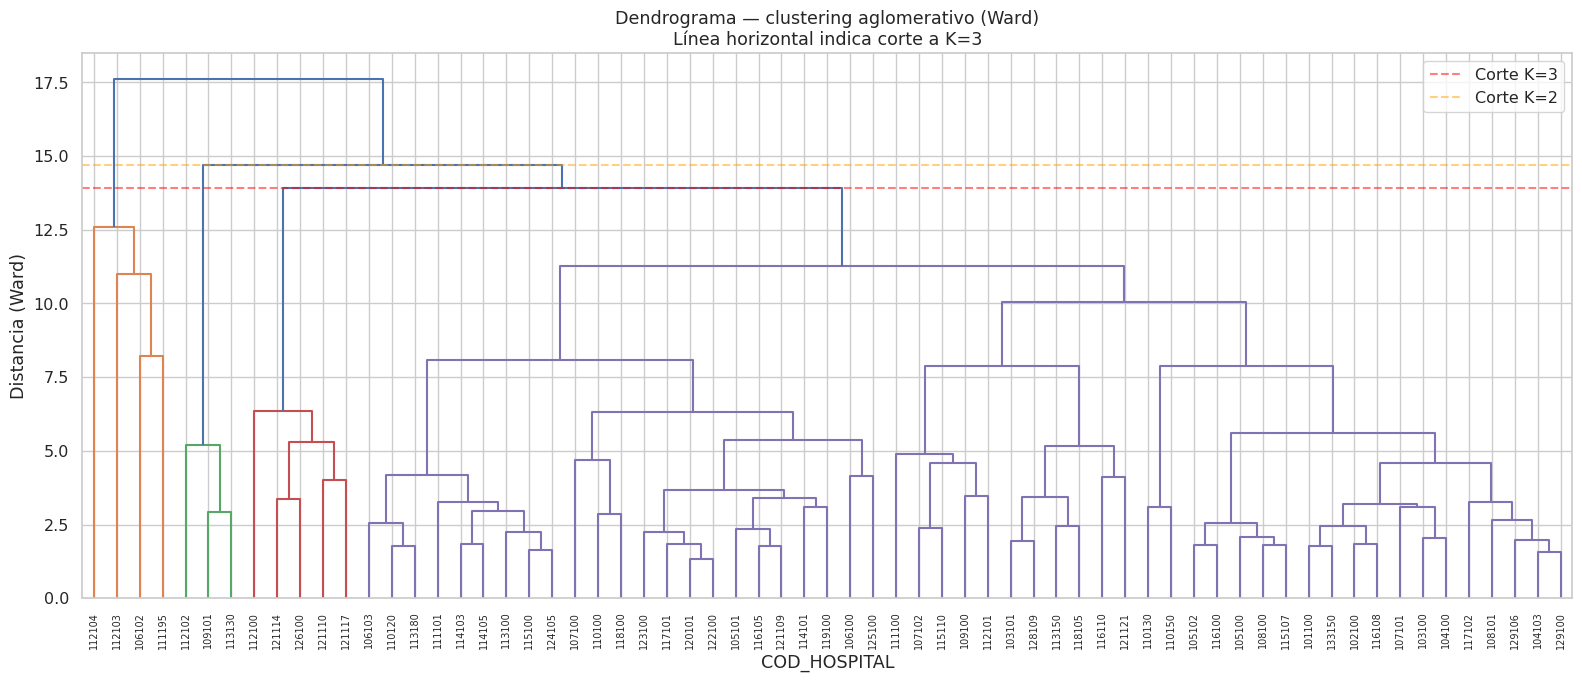

In [5]:
# Dendrograma con cortes coloreados
Z = linkage(X, method='ward')
fig, ax = plt.subplots(figsize=(16, 7))
dendrogram(
    Z, labels=ids_hospitales,
    leaf_rotation=90, leaf_font_size=7,
    color_threshold=Z[-3, 2],  # corte para 3 clusters
)
ax.set_title('Dendrograma — clustering aglomerativo (Ward)\nLínea horizontal indica corte a K=3')
ax.set_xlabel('COD_HOSPITAL')
ax.set_ylabel('Distancia (Ward)')
ax.axhline(Z[-3, 2], color='red', linestyle='--', alpha=0.5, label='Corte K=3')
ax.axhline(Z[-2, 2], color='orange', linestyle='--', alpha=0.5, label='Corte K=2')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'dendrograma_ward.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.4 Método 3 — HDBSCAN (no especifica K)

HDBSCAN encuentra clusters de **densidad variable** y etiqueta como `-1` los hospitales que no caben en ningún grupo (outliers explícitos).

In [6]:
df_hdb, labels_hdb = hdbscan_rango(X, min_cluster_sizes=(3, 4, 5, 6, 8))
print('HDBSCAN — métricas por min_cluster_size:')
print(df_hdb.to_string(index=False))

print('\nDistribución por cluster (incluye -1 = outliers):')
for cfg, labs in labels_hdb.items():
    dist = pd.Series(labs).value_counts().sort_index().to_dict()
    print(f'  {cfg}: {dist}')

HDBSCAN — métricas por min_cluster_size:
 metodo             config  n_clusters_efectivos  n_outliers  silhouette  calinski_harabasz  davies_bouldin
HDBSCAN min_cluster_size=3                     3          47      0.2109             5.7581          1.3350
HDBSCAN min_cluster_size=4                     2          51      0.2108             4.9574          1.4919
HDBSCAN min_cluster_size=5                     2          53      0.2651             5.8566          1.2550
HDBSCAN min_cluster_size=6                     0          65     -1.0000             0.0000             inf
HDBSCAN min_cluster_size=8                     0          65     -1.0000             0.0000             inf

Distribución por cluster (incluye -1 = outliers):
  min_cluster_size=3: {-1: 47, 0: 7, 1: 3, 2: 8}
  min_cluster_size=4: {-1: 51, 0: 8, 1: 6}
  min_cluster_size=5: {-1: 53, 0: 7, 1: 5}
  min_cluster_size=6: {-1: 65}
  min_cluster_size=8: {-1: 65}


## 5.5 Método 4 — KNN-graph + Leiden

Construye un grafo donde cada hospital se conecta con sus `k_nn` vecinos más cercanos, luego aplica el algoritmo Leiden para detectar comunidades. La **resolución** controla cuántas comunidades emergen (más alta = más comunidades).

In [7]:
df_leiden, labels_leiden = knn_leiden_rango(
    X,
    n_neighbors_list=(10, 15, 20),
    resoluciones=(0.5, 1.0, 1.5, 2.0),
)
print('KNN-graph + Leiden — métricas:')
print(df_leiden.to_string(index=False))

print('\nDistribución por cluster:')
for cfg, labs in labels_leiden.items():
    dist = pd.Series(labs).value_counts().sort_index().tolist()
    print(f'  {cfg}: {dist}')

KNN-graph + Leiden — métricas:
            metodo           config  n_clusters_efectivos  silhouette  calinski_harabasz  davies_bouldin
KNN-graph + Leiden k_nn=10, res=0.5                     2      0.0952             7.8468          2.4459
KNN-graph + Leiden k_nn=10, res=1.0                     3      0.0805             6.9094          2.1449
KNN-graph + Leiden k_nn=10, res=1.5                     6      0.0495             5.1824          2.1158
KNN-graph + Leiden k_nn=10, res=2.0                     9     -0.1862             3.8617          1.8997
KNN-graph + Leiden k_nn=15, res=0.5                     1     -1.0000             0.0000             inf
KNN-graph + Leiden k_nn=15, res=1.0                     3      0.0712             7.0367          2.1184
KNN-graph + Leiden k_nn=15, res=1.5                     8     -0.2321             3.6867          1.8599
KNN-graph + Leiden k_nn=15, res=2.0                    13     -0.2167             2.7818          1.6778
KNN-graph + Leiden k_nn=

## 5.6 Método 5 — Gaussian Mixture Model + BIC

In [8]:
df_gmm, labels_gmm = gmm_rango(X, k_grid=tuple(range(2, 9)))
print('GMM — métricas por K (incluye BIC):')
print(df_gmm.to_string(index=False))

if not df_gmm.empty:
    K_OPTIMO_BIC = int(df_gmm.loc[df_gmm['bic'].idxmin(), 'n_clusters_efectivos'])
    print(f'\n>>> K óptimo según BIC mínimo: {K_OPTIMO_BIC}')

print('\nDistribución por cluster:')
for k, labs in labels_gmm.items():
    dist = pd.Series(labs).value_counts().sort_index().tolist()
    print(f'  K={k}: {dist}')

GMM — métricas por K (incluye BIC):
metodo config  n_clusters_efectivos       bic       aic  silhouette  calinski_harabasz  davies_bouldin
   GMM    K=2                     2 2805.7391 1981.6464      0.2241            10.0220          2.1738
   GMM    K=3                     3 2487.3986 1250.1722      0.0705             7.3154          2.2782
   GMM    K=4                     4 2626.0568  975.6968      0.0882             8.1261          1.7536
   GMM    K=5                     5 2390.0880  326.5945      0.0616             7.4193          1.8272
   GMM    K=6                     6 2258.4840 -218.1431      0.0875             8.3382          1.5746
   GMM    K=7                     7 2759.9876 -129.7731      0.1010             9.6312          1.3724
   GMM    K=8                     8 2773.5323 -529.3619      0.1297            10.9864          1.2145

>>> K óptimo según BIC mínimo: 6

Distribución por cluster:
  K=2: [17, 48]
  K=3: [15, 16, 34]
  K=4: [12, 15, 37, 1]
  K=5: [8, 14, 26, 1

## 5.7 Tabla comparativa unificada

In [9]:
df_global = pd.concat(
    [df_kmeans, df_agg, df_hdb, df_leiden, df_gmm],
    ignore_index=True, sort=False,
)

# Reordenar columnas para legibilidad
cols_orden = ['metodo', 'config', 'n_clusters_efectivos', 'silhouette',
              'calinski_harabasz', 'davies_bouldin']
if 'n_outliers' in df_global.columns:
    cols_orden.insert(3, 'n_outliers')
if 'bic' in df_global.columns:
    cols_orden += ['bic', 'aic']
df_global = df_global[[c for c in cols_orden if c in df_global.columns]]
df_global = df_global.sort_values('silhouette', ascending=False).reset_index(drop=True)

df_global.to_csv(TABLES_DIR / 'clustering_alternativos_comparacion.csv', index=False)
print(f'Persistido: clustering_alternativos_comparacion.csv  ({len(df_global)} filas)')
print()
print('=== TOP 10 configuraciones por Silhouette ===')
print(df_global.head(10).to_string(index=False))

Persistido: clustering_alternativos_comparacion.csv  (38 filas)

=== TOP 10 configuraciones por Silhouette ===
             metodo             config  n_clusters_efectivos  n_outliers  silhouette  calinski_harabasz  davies_bouldin       bic       aic
          K-means++                K=2                     2         NaN      0.4845            10.8606          1.5133       NaN       NaN
Aglomerativo (Ward)                K=2                     2         NaN      0.4845            10.8606          1.5133       NaN       NaN
Aglomerativo (Ward)                K=3                     3         NaN      0.3784            10.2876          1.3270       NaN       NaN
Aglomerativo (Ward)                K=5                     5         NaN      0.3032            10.6956          1.0318       NaN       NaN
Aglomerativo (Ward)                K=4                     4         NaN      0.2991            10.5209          1.2978       NaN       NaN
            HDBSCAN min_cluster_size=5           

In [10]:
# ARI cruzado entre los mejores resultados de cada método
all_labels = {}
for k, labs in labels_kmeans.items():
    all_labels[f'kmeans_K={k}'] = labs
for k, labs in labels_agg.items():
    all_labels[f'aggl_K={k}'] = labs
for cfg, labs in labels_hdb.items():
    all_labels[f'hdbscan_{cfg}'] = labs
for cfg, labs in labels_leiden.items():
    all_labels[f'leiden_{cfg}'] = labs
for k, labs in labels_gmm.items():
    all_labels[f'gmm_K={k}'] = labs

df_ari = comparar_etiquetas(all_labels)
df_ari.to_csv(TABLES_DIR / 'clustering_alternativos_ari_cruzado.csv', index=False)

# Top 15 pares más concordantes
print('=== TOP 15 pares con mayor ARI (mayor concordancia) ===')
print(df_ari.head(15).to_string(index=False))

=== TOP 15 pares con mayor ARI (mayor concordancia) ===
                  metodo_1                   metodo_2    ARI
                kmeans_K=2                   aggl_K=2 1.0000
   leiden_k_nn=15, res=0.5    leiden_k_nn=20, res=0.5 1.0000
hdbscan_min_cluster_size=6 hdbscan_min_cluster_size=8 1.0000
hdbscan_min_cluster_size=6    leiden_k_nn=15, res=0.5 1.0000
hdbscan_min_cluster_size=6    leiden_k_nn=20, res=0.5 1.0000
hdbscan_min_cluster_size=8    leiden_k_nn=15, res=0.5 1.0000
hdbscan_min_cluster_size=8    leiden_k_nn=20, res=0.5 1.0000
                  aggl_K=6                   aggl_K=7 0.9979
                  aggl_K=4                   aggl_K=5 0.9967
                   gmm_K=6                    gmm_K=7 0.9864
                kmeans_K=3                 kmeans_K=4 0.9845
hdbscan_min_cluster_size=4 hdbscan_min_cluster_size=5 0.8778
                kmeans_K=3                    gmm_K=2 0.8678
                kmeans_K=4                    gmm_K=2 0.8526
                   gmm_K=3   

## 5.8 Visualización PCA 2D — comparación de los 5 mejores resultados

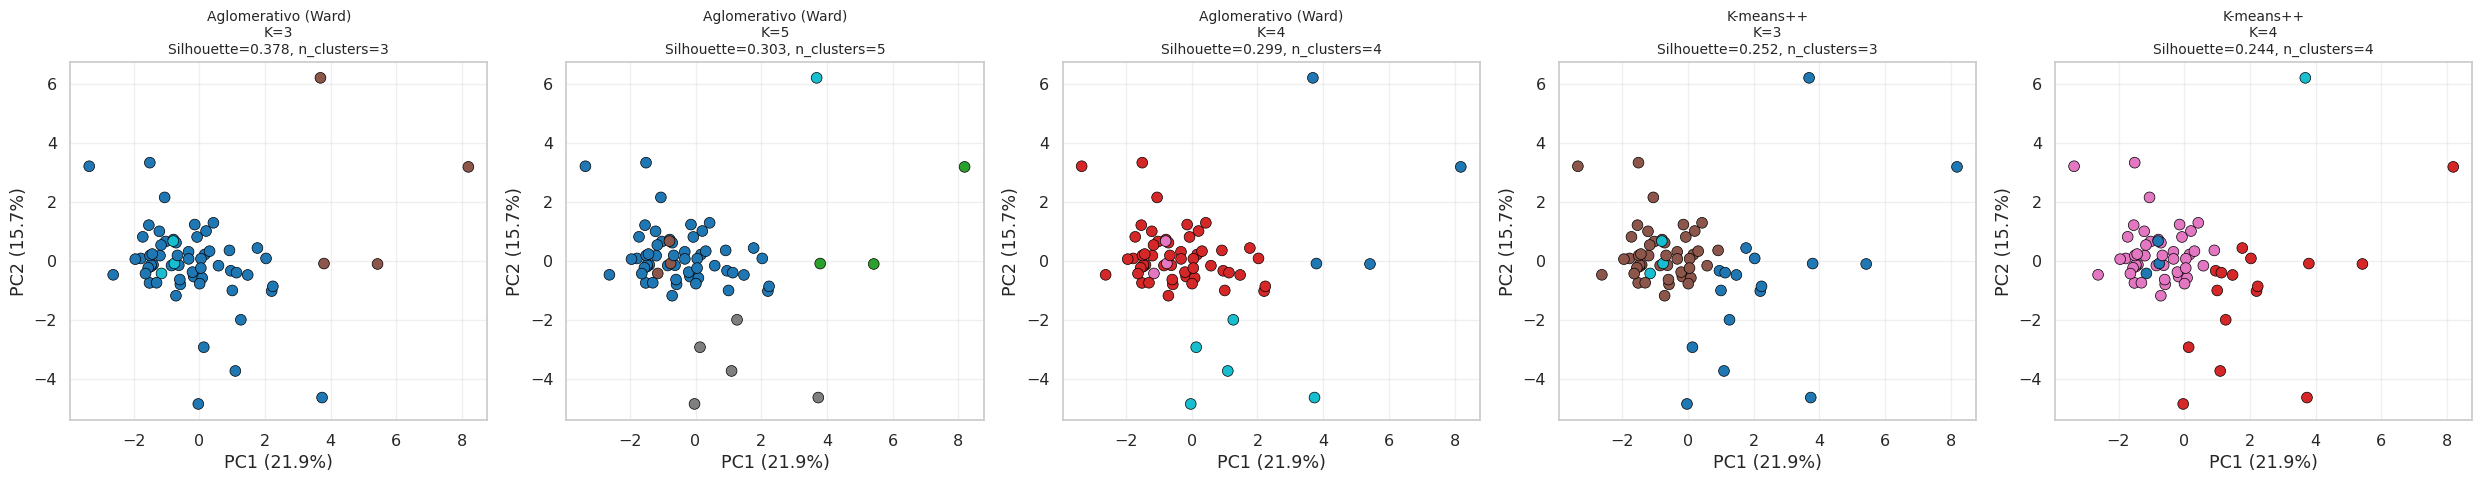

In [11]:
# Coordenadas PCA 2D para visualizar todos los métodos
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)

# Top 5 configuraciones con mejor Silhouette y al menos 3 clusters
top_configs = df_global[df_global['n_clusters_efectivos'] >= 3].head(5)

fig, axes = plt.subplots(1, len(top_configs), figsize=(5 * len(top_configs), 5))
if len(top_configs) == 1:
    axes = [axes]

for ax, (_, fila) in zip(axes, top_configs.iterrows()):
    metodo = fila['metodo']
    cfg = fila['config']
    sil = fila['silhouette']
    n_clu = fila['n_clusters_efectivos']
    
    # Buscar las etiquetas correspondientes
    key = None
    if 'K-means' in metodo:
        k = int(cfg.split('=')[1])
        key, labs = f'kmeans_K={k}', labels_kmeans[k]
    elif 'Aglomerativo' in metodo:
        k = int(cfg.split('=')[1])
        key, labs = f'aggl_K={k}', labels_agg[k]
    elif 'HDBSCAN' in metodo:
        key, labs = f'hdbscan_{cfg}', labels_hdb[cfg]
    elif 'Leiden' in metodo:
        key, labs = f'leiden_{cfg}', labels_leiden[cfg]
    elif 'GMM' in metodo:
        k = int(cfg.split('=')[1])
        key, labs = f'gmm_K={k}', labels_gmm[k]
    
    # Scatter coloreado
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=labs, cmap='tab10',
                    s=60, edgecolors='black', linewidth=0.5)
    ax.set_title(f'{metodo}\n{cfg}\nSilhouette={sil:.3f}, n_clusters={n_clu}',
                 fontsize=10)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'clustering_alternativos_pca2d.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.9 Recomendación final

In [12]:
# Filtrar configuraciones con al menos 3 clusters y Silhouette > 0.20
candidatos = df_global[
    (df_global['n_clusters_efectivos'] >= 3)
    & (df_global['silhouette'] > 0.20)
].copy()

if not candidatos.empty:
    print('=== Configuraciones candidatas (≥3 clusters, Silhouette > 0.20) ===')
    print(candidatos.head(10).to_string(index=False))
    print()
    mejor = candidatos.iloc[0]
    print('>>> RECOMENDACIÓN: ')
    print(f'    Método:       {mejor["metodo"]}')
    print(f'    Configuración: {mejor["config"]}')
    print(f'    N clusters:    {mejor["n_clusters_efectivos"]}')
    print(f'    Silhouette:    {mejor["silhouette"]:.4f}')
    print(f'    Calinski-H:    {mejor["calinski_harabasz"]:.2f}')
else:
    print('Ningún método con ≥3 clusters supera Silhouette > 0.20')
    print('Considerar mantener K=2 como resultado principal')

# Persistir recomendación a JSON
import json
if not candidatos.empty:
    mejor_dict = candidatos.iloc[0].to_dict()
    (ROOT / 'data' / 'processed' / 'recomendacion_alternativos.json').write_text(
        json.dumps(mejor_dict, indent=2, default=str)
    )
    print(f'\nRecomendación guardada en data/processed/recomendacion_alternativos.json')

=== Configuraciones candidatas (≥3 clusters, Silhouette > 0.20) ===
             metodo             config  n_clusters_efectivos  n_outliers  silhouette  calinski_harabasz  davies_bouldin  bic  aic
Aglomerativo (Ward)                K=3                     3         NaN      0.3784            10.2876          1.3270  NaN  NaN
Aglomerativo (Ward)                K=5                     5         NaN      0.3032            10.6956          1.0318  NaN  NaN
Aglomerativo (Ward)                K=4                     4         NaN      0.2991            10.5209          1.2978  NaN  NaN
          K-means++                K=3                     3         NaN      0.2521             9.6682          1.7273  NaN  NaN
          K-means++                K=4                     4         NaN      0.2441            10.1843          1.3051  NaN  NaN
            HDBSCAN min_cluster_size=3                     3     47.0000      0.2109             5.7581          1.3350  NaN  NaN

>>> RECOMENDACIÓN: 
 